In [144]:
import polars as pl

In [145]:
FILTER = "ASH_COATED_OSMIUM"
# FILTER = "INTARIAN_PEPPER_ROOT"

DAY = 2

In [146]:

# Quotes (order book snapshots)
quotes = pl.read_csv(
    f"data/orders_day{DAY}.csv",
    separator=";",
    null_values=[""]
)


# Trades
trades = pl.read_csv(
    f"data/trades_day{DAY}.csv",
    separator=";",
    null_values=[""]
)



quotes = quotes.filter(pl.col("product")==FILTER)
trades = trades.filter(pl.col("symbol")==FILTER)

print(quotes.head())
print(trades.head())

shape: (5, 17)
┌─────┬───────────┬────────────┬────────────┬───┬────────────┬────────────┬───────────┬────────────┐
│ day ┆ timestamp ┆ product    ┆ bid_price_ ┆ … ┆ ask_price_ ┆ ask_volume ┆ mid_price ┆ profit_and │
│ --- ┆ ---       ┆ ---        ┆ 1          ┆   ┆ 3          ┆ _3         ┆ ---       ┆ _loss      │
│ i64 ┆ i64       ┆ str        ┆ ---        ┆   ┆ ---        ┆ ---        ┆ f64       ┆ ---        │
│     ┆           ┆            ┆ i64        ┆   ┆ i64        ┆ i64        ┆           ┆ f64        │
╞═════╪═══════════╪════════════╪════════════╪═══╪════════════╪════════════╪═══════════╪════════════╡
│ -2  ┆ 0         ┆ ASH_COATED ┆ null       ┆ … ┆ null       ┆ null       ┆ 10010.0   ┆ 0.0        │
│     ┆           ┆ _OSMIUM    ┆            ┆   ┆            ┆            ┆           ┆            │
│ -2  ┆ 100       ┆ ASH_COATED ┆ 9992       ┆ … ┆ null       ┆ null       ┆ 10000.0   ┆ 0.0        │
│     ┆           ┆ _OSMIUM    ┆            ┆   ┆            ┆            ┆ 

In [147]:
quotes = quotes.with_columns([
    pl.col("timestamp").cast(pl.Int64),
    pl.col("mid_price").cast(pl.Float64)
])

quotes = quotes.with_columns([
    pl.col("bid_price_1").alias("best_bid"),
    pl.col("ask_price_1").alias("best_ask"),
    (pl.col("ask_price_1") - pl.col("bid_price_1")).alias("spread")
])

trades = trades.with_columns([
    pl.col("timestamp").cast(pl.Int64),
    pl.col("price").cast(pl.Float64),
    pl.col("quantity").cast(pl.Int64)
])

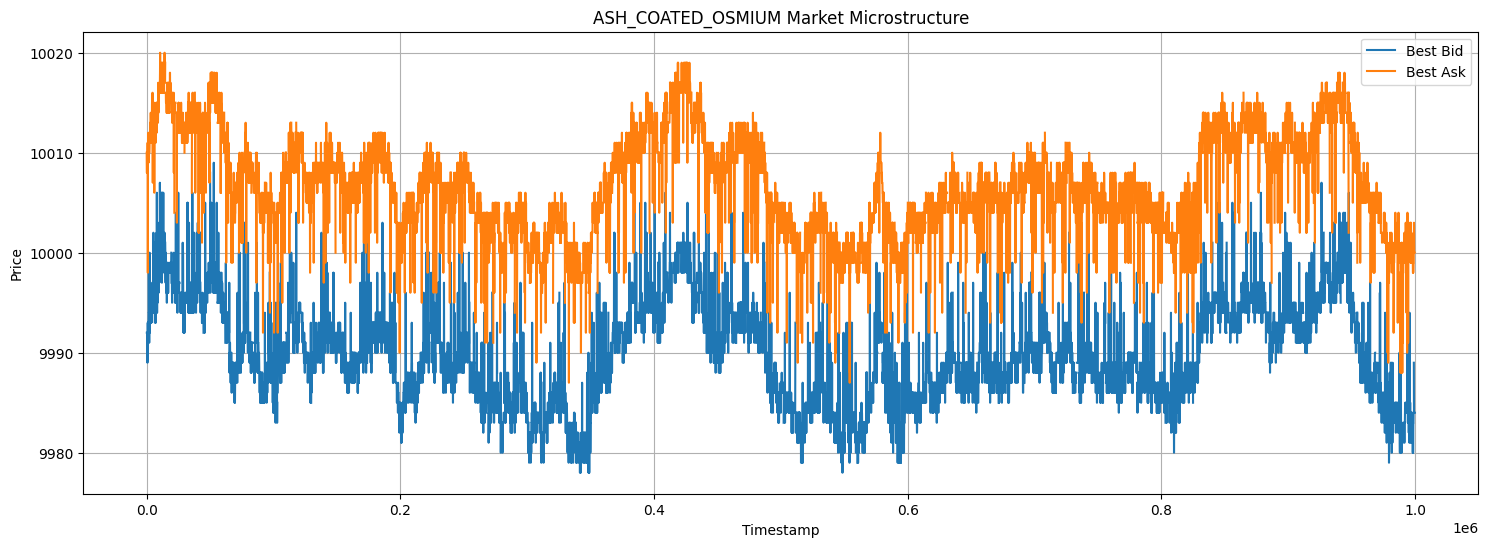

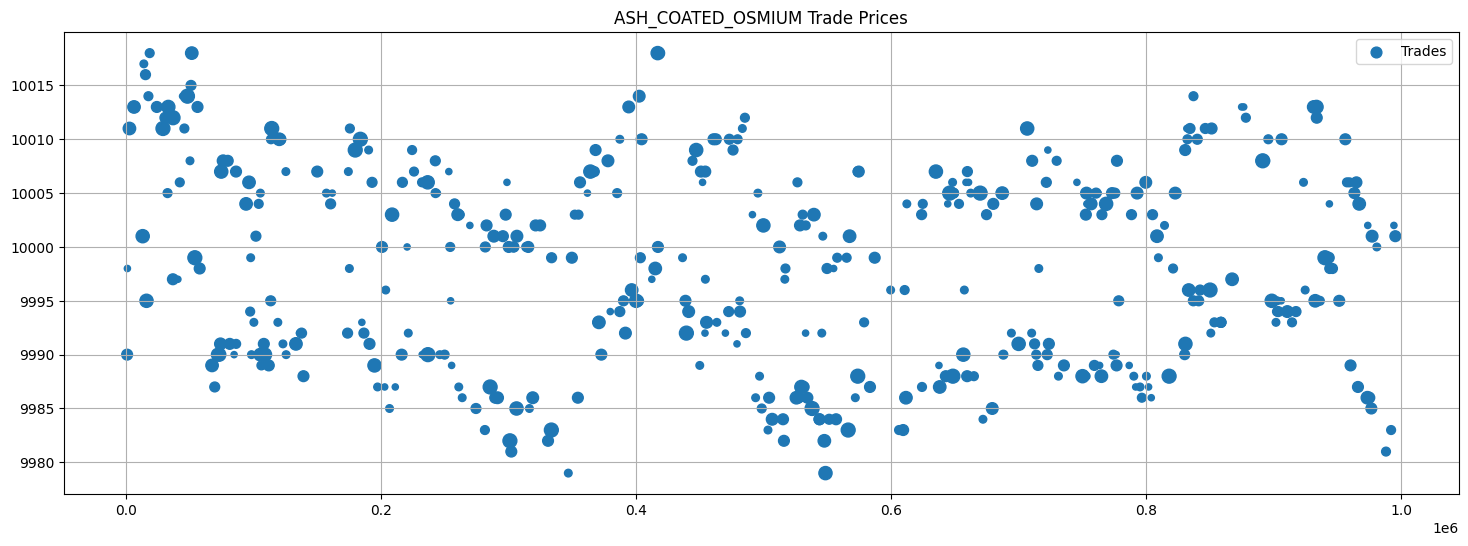

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

# # Order book lines
plt.plot(quotes["timestamp"], quotes["best_bid"], label="Best Bid")
plt.plot(quotes["timestamp"], quotes["best_ask"], label="Best Ask")
# plt.plot(quotes["timestamp"], quotes["mid_price"], label="Mid Price")

plt.title(f"{FILTER} Market Microstructure")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(18, 6))
plt.scatter(
    trades["timestamp"],
    trades["price"],
    s=trades["quantity"] * 10,
    marker="o",
    label="Trades"
)
plt.title(f"{FILTER} Trade Prices")
plt.legend()
plt.grid()

plt.show()


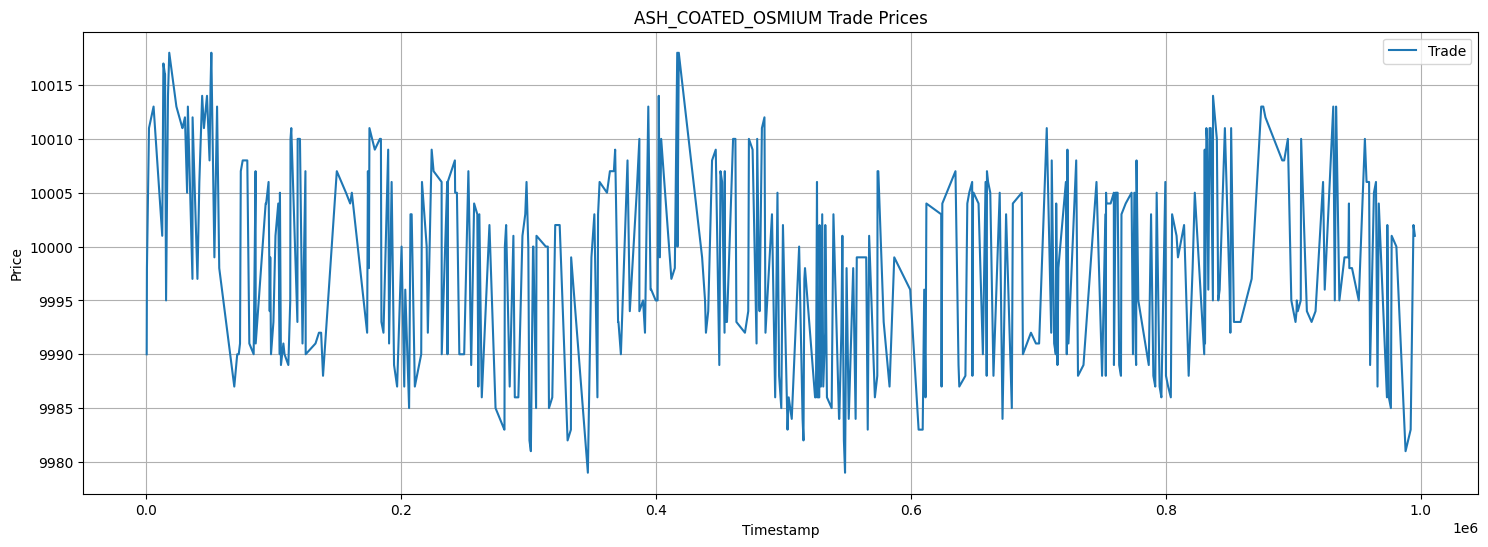

In [149]:
plt.figure(figsize=(18, 6))

# # Trade Prices
plt.plot(trades["timestamp"], trades["price"], label="Trade")

plt.title(f"{FILTER} Trade Prices")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()


In [150]:

result = quotes.select([
    (pl.col("best_bid").diff().abs() > 3).sum().alias("bid_jumps"),
    (pl.col("best_ask").diff().abs() > 3).sum().alias("ask_jumps"),
])

print(result)

shape: (1, 2)
┌───────────┬───────────┐
│ bid_jumps ┆ ask_jumps │
│ ---       ┆ ---       │
│ u32       ┆ u32       │
╞═══════════╪═══════════╡
│ 812       ┆ 738       │
└───────────┴───────────┘


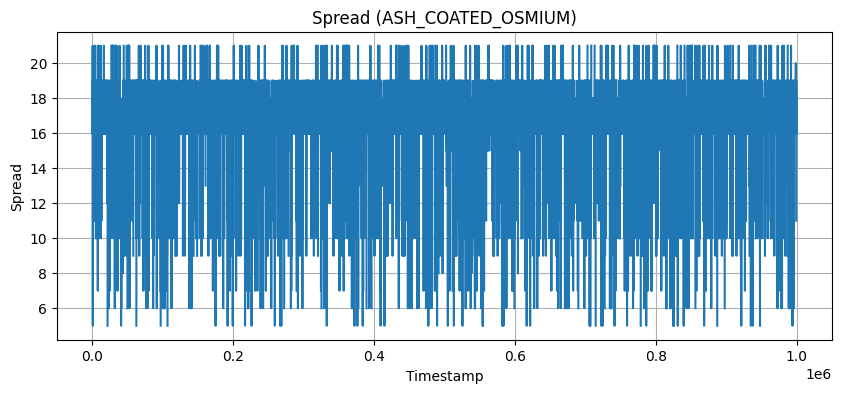

In [151]:
plt.figure(figsize=(10, 4))

plt.plot(quotes["timestamp"], quotes["spread"])

plt.title(f"Spread ({FILTER})")
plt.xlabel("Timestamp")
plt.ylabel("Spread")

plt.grid()
plt.show()

In [152]:
quotes

day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,best_bid,best_ask,spread
i64,i64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,i64
-2,0,"""ASH_COATED_OSMIUM""",null,null,null,null,null,null,10010,25,null,null,null,null,10010.0,0.0,null,10010,null
-2,100,"""ASH_COATED_OSMIUM""",9992,15,null,null,null,null,10008,15,10011,20,null,null,10000.0,0.0,9992,10008,16
-2,200,"""ASH_COATED_OSMIUM""",9992,15,9989,30,null,null,10008,15,10010,30,null,null,10000.0,0.0,9992,10008,16
-2,300,"""ASH_COATED_OSMIUM""",9992,13,9989,26,null,null,10008,13,10010,26,null,null,10000.0,0.0,9992,10008,16
-2,400,"""ASH_COATED_OSMIUM""",9992,15,null,null,null,null,10008,15,10010,20,null,null,10000.0,0.0,9992,10008,16
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-2,999500,"""ASH_COATED_OSMIUM""",9984,13,9982,24,null,null,10000,13,10003,24,null,null,9992.0,0.0,9984,10000,16
-2,999600,"""ASH_COATED_OSMIUM""",9984,15,9982,30,null,null,10000,15,10003,30,null,null,9992.0,0.0,9984,10000,16
-2,999700,"""ASH_COATED_OSMIUM""",9984,10,9982,22,null,null,10000,10,10003,22,null,null,9992.0,0.0,9984,10000,16


Readable log written to: ../106022/106022_readable.log
TRADING LOG ANALYSIS

Total rows loaded : 1824
Products          : ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
Timestamp range   : 0 – 99900
Days in log       : [0]

--- Per-product summary ---
shape: (2, 12)
┌────────────┬───────┬───────────┬─────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ product    ┆ ticks ┆ final_pnl ┆ min_pnl ┆ … ┆ avg_mid    ┆ std_mid    ┆ avg_bid_vo ┆ avg_ask_vo │
│ ---        ┆ ---   ┆ ---       ┆ ---     ┆   ┆ ---        ┆ ---        ┆ l          ┆ l          │
│ str        ┆ u32   ┆ f64       ┆ f64     ┆   ┆ f64        ┆ f64        ┆ ---        ┆ ---        │
│            ┆       ┆           ┆         ┆   ┆            ┆            ┆ f64        ┆ f64        │
╞════════════╪═══════╪═══════════╪═════════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ ASH_COATED ┆ 912   ┆ 382.71875 ┆ 0.0     ┆ … ┆ 9978.06195 ┆ 468.047951 ┆ 14.906574  ┆ 14.595238  │
│ _OSMIUM    ┆       ┆     

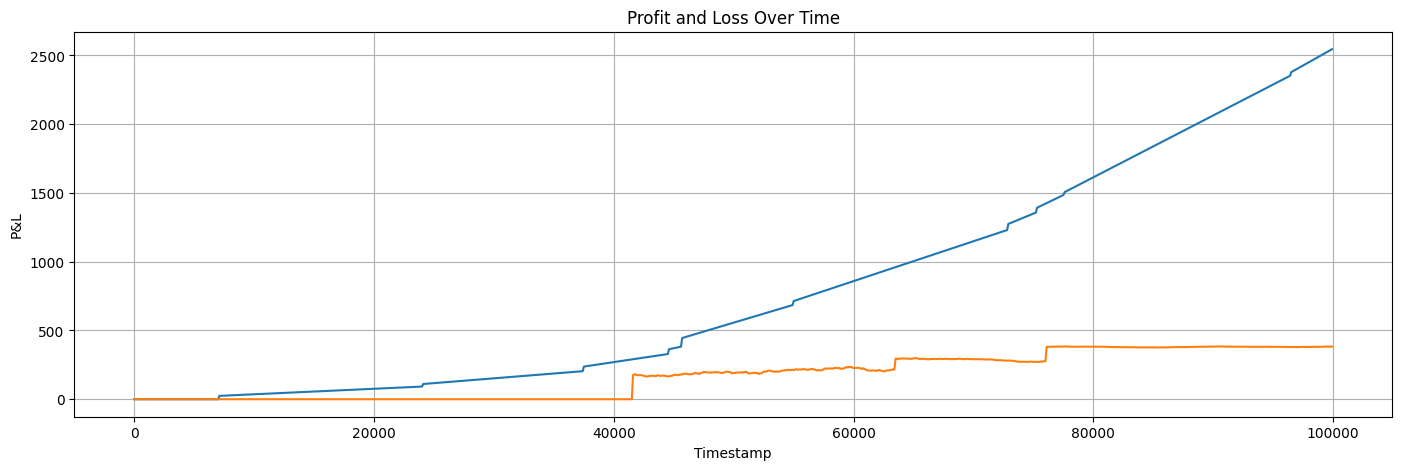

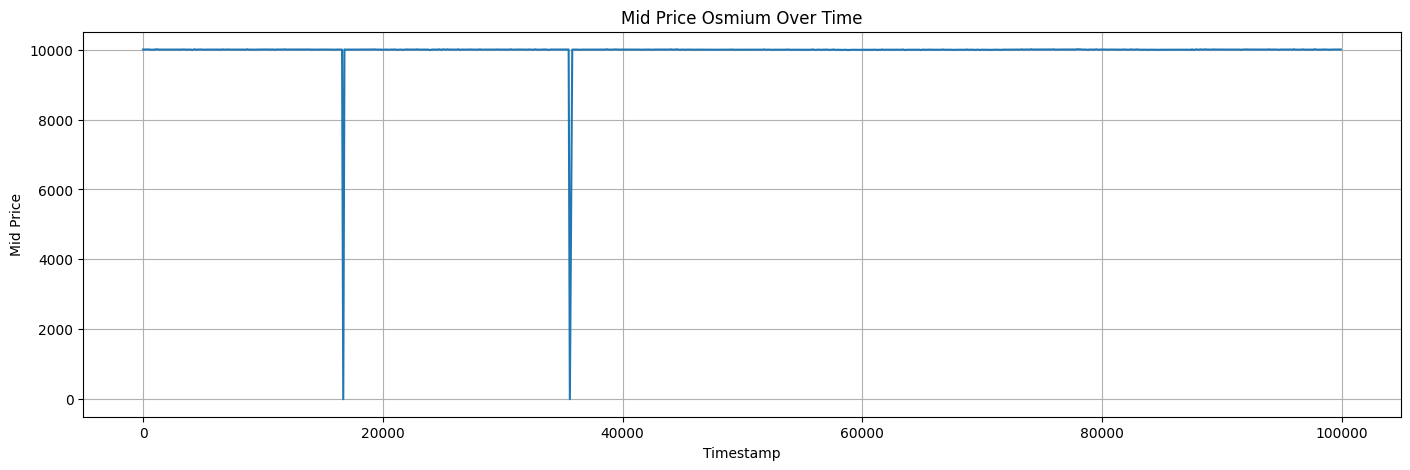

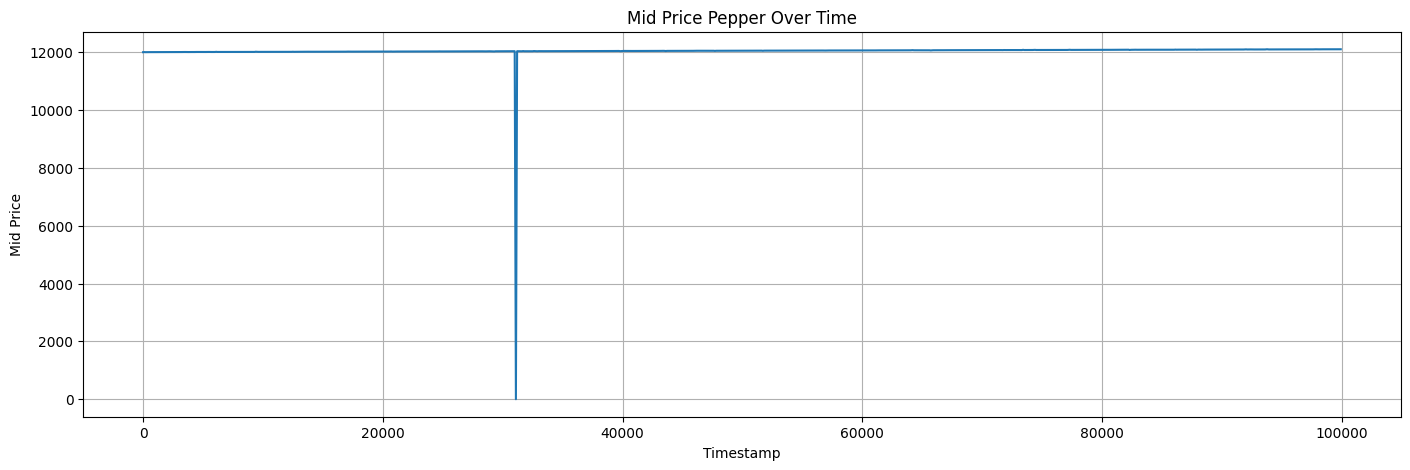

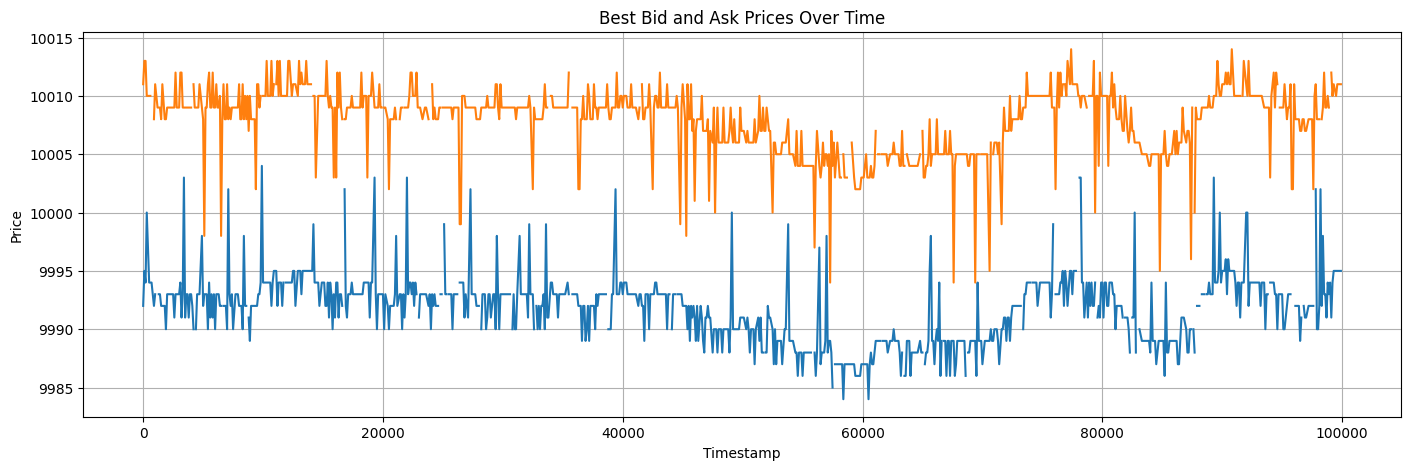

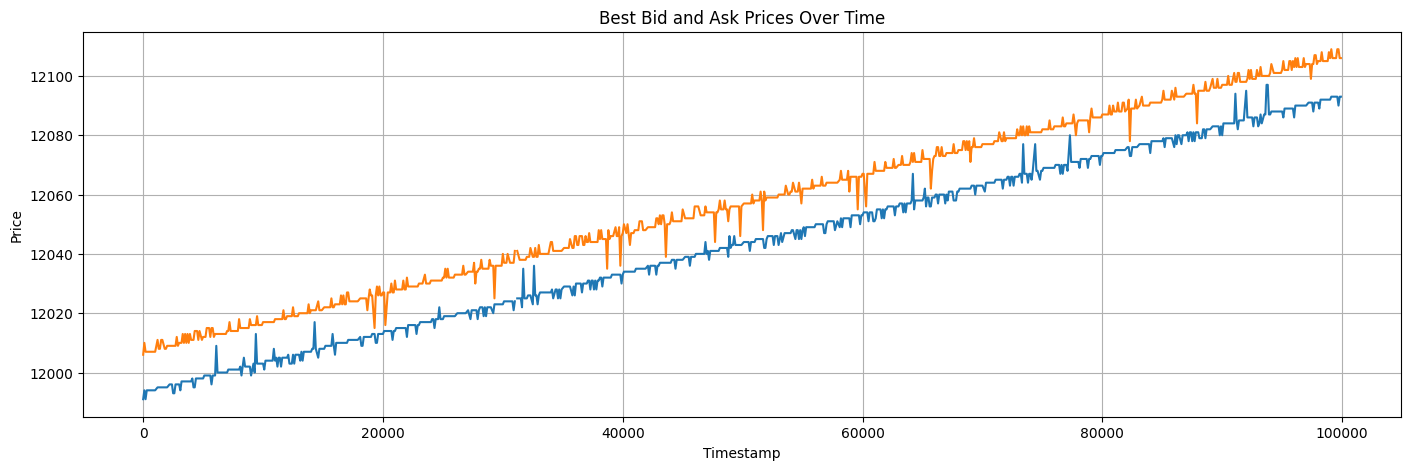

C:\Users\maehl\AppData\Local\Temp\ipykernel_16472\57007294.py:295: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


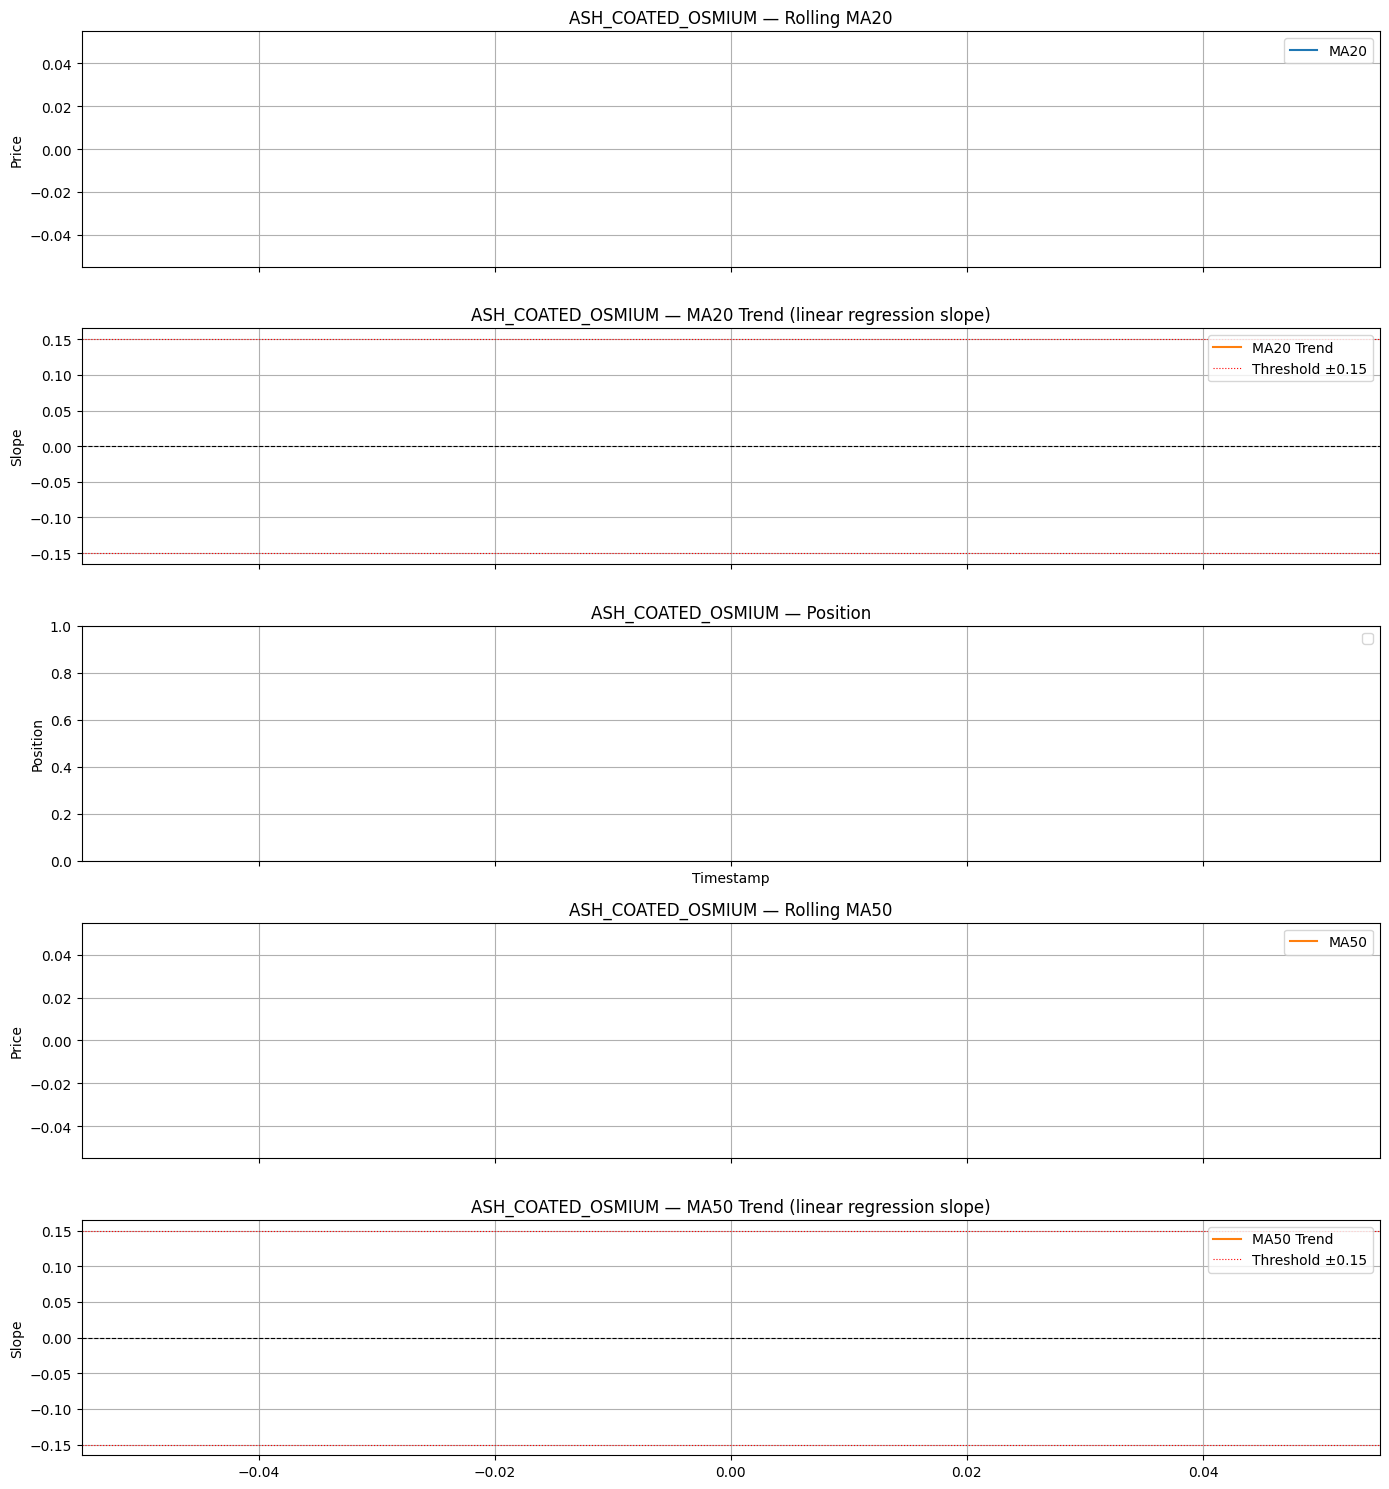


Trades CSV saved to: 106022/106022_trades.csv
shape: (13, 5)
┌──────────────────────┬──────┬─────────┬──────────┬─────────────────┐
│ product              ┆ side ┆ price   ┆ quantity ┆ trade_timestamp │
│ ---                  ┆ ---  ┆ ---     ┆ ---      ┆ ---             │
│ str                  ┆ str  ┆ f64     ┆ i64      ┆ i64             │
╞══════════════════════╪══════╪═════════╪══════════╪═════════════════╡
│ ASH_COATED_OSMIUM    ┆ SELL ┆ 10020.0 ┆ 9        ┆ 41500           │
│ ASH_COATED_OSMIUM    ┆ BUY  ┆ 9980.0  ┆ 5        ┆ 63400           │
│ ASH_COATED_OSMIUM    ┆ BUY  ┆ 9980.0  ┆ 5        ┆ 76000           │
│ INTARIAN_PEPPER_ROOT ┆ BUY  ┆ 12001.0 ┆ 4        ┆ 7000            │
│ INTARIAN_PEPPER_ROOT ┆ BUY  ┆ 12018.0 ┆ 3        ┆ 24000           │
│ …                    ┆ …    ┆ …       ┆ …        ┆ …               │
│ INTARIAN_PEPPER_ROOT ┆ BUY  ┆ 12046.0 ┆ 3        ┆ 54900           │
│ INTARIAN_PEPPER_ROOT ┆ BUY  ┆ 12067.0 ┆ 7        ┆ 72800           │
│ INTARIAN_PEPP

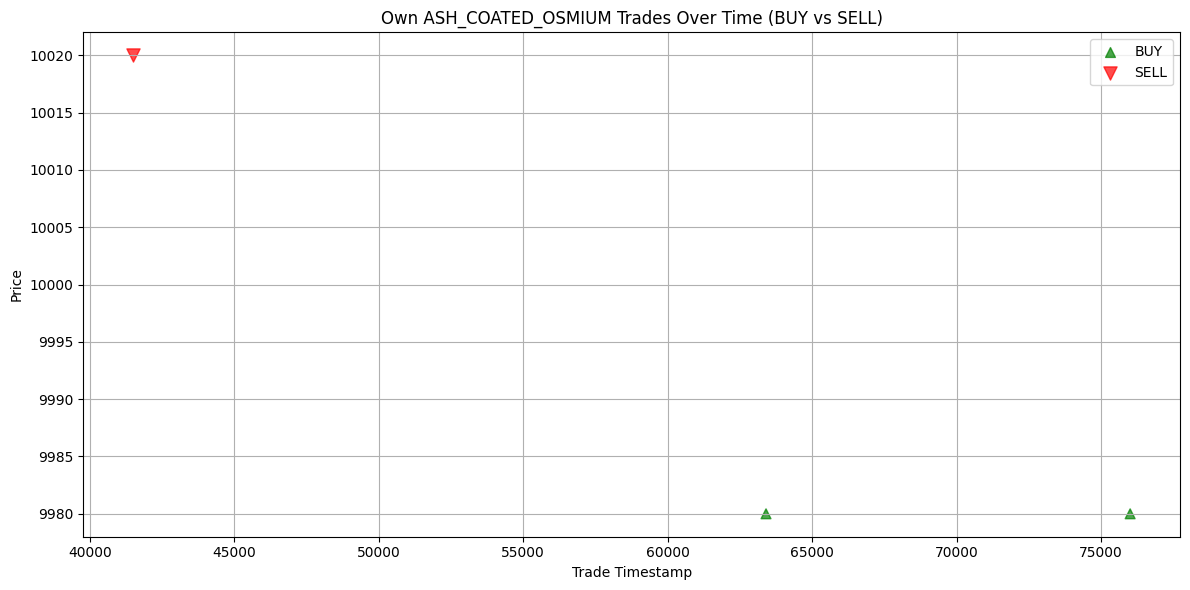

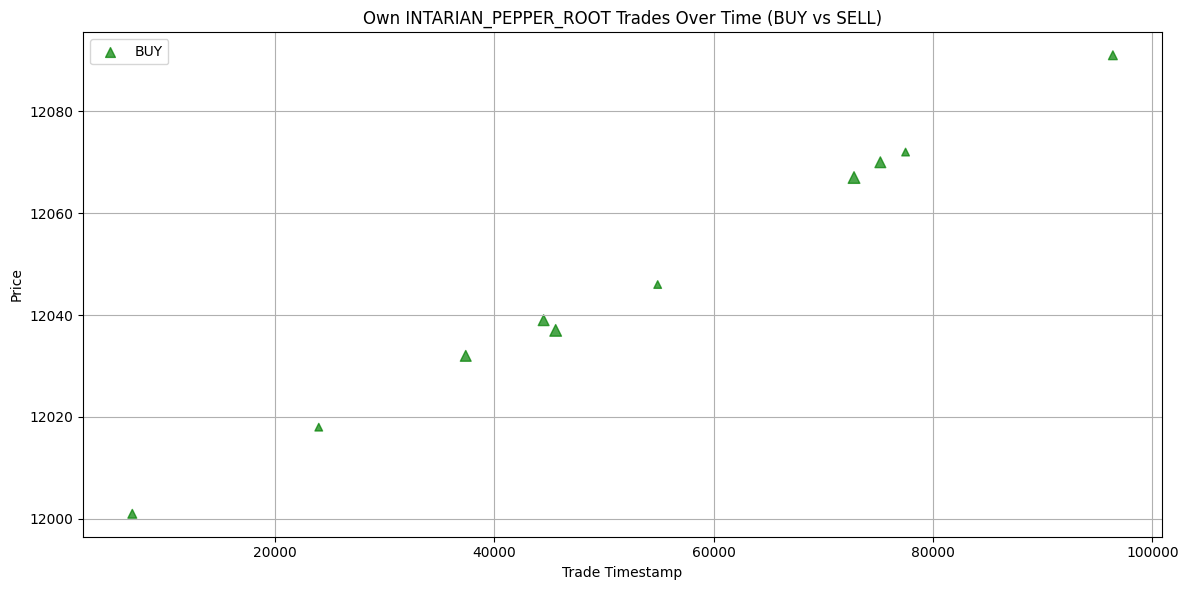


Enriched CSV saved to: ../106022/106022_enriched


In [157]:
import polars as pl
import json
import re
import sys
import json
import argparse
from pathlib import Path
from io import StringIO
import matplotlib.pyplot as plt

# FILTER = "ASH_COATED_OSMIUM"
# FILTER = "INTARIAN_PEPPER_ROOT"

def parse_log_file(path: str) -> pl.DataFrame:
    """
    Parse a trading log file (JSON with embedded CSV activitiesLog) into a Polars DataFrame.
    Supports both .json log files and raw .csv/.log files.
    """
    with open(path, "r") as f:
        content = f.read().strip()

    # Try JSON format first (log file wraps CSV in activitiesLog key)
    csv_text = None
    try:
        data = json.loads(content)
        csv_text = data.get("activitiesLog", "")
    except json.JSONDecodeError:
        # Might be raw CSV or a JSON-lines file — try extracting activitiesLog from first line
        first_line = content.split("\n")[0]
        try:
            data = json.loads(first_line)
            csv_text = data.get("activitiesLog", "")
        except json.JSONDecodeError:
            # Treat entire file as raw CSV
            csv_text = content

    if not csv_text:
        raise ValueError("No CSV data found in log file.")

    df = pl.read_csv(
        StringIO(csv_text),
        separator=";",
        null_values=[""],
        infer_schema_length=1000,
    )
    return df

def parse_own_trades(data: dict) -> pl.DataFrame:
    """Extract own trades from lambda logs into a DataFrame."""
    records = []
    for entry in data.get("logs", []):
        ts = entry.get("timestamp")
        lambda_log = entry.get("lambdaLog", "")

        match = re.search(r'Own Trades:\s*(\{.*?\})', lambda_log)
        if not match:
            continue

        raw = match.group(1).replace("'", '"')

        # Extract each product's trade list: "PRODUCT": [(...)]
        for product_match in re.finditer(r'"(\w+)":\s*\[([^\]]*)\]', raw):
            product = product_match.group(1)
            trades_str = product_match.group(2).strip()
            if not trades_str:
                continue

            # Each trade is a tuple: (SYMBOL, BUYER << SELLER, price, qty, timestamp)
            for trade_match in re.finditer(
                r'\((\w+),\s*(.*?),\s*([\d.]+),\s*(\d+),\s*(\d+)\)', trades_str
            ):
                raw_counterparty = trade_match.group(2).strip()
                # SUBMISSION << X  = we bought (we are buyer)
                # X << SUBMISSION  = we sold (we are seller)
                if "SUBMISSION <<" in raw_counterparty:
                    side = "BUY"
                elif "<< SUBMISSION" in raw_counterparty:
                    side = "SELL"
                else:
                    side = "UNKNOWN"

                records.append({
                    "log_timestamp": float(ts),
                    "product": product,
                    "side": side,
                    "price": float(trade_match.group(3)),
                    "quantity": int(trade_match.group(4)),
                    "trade_timestamp": int(trade_match.group(5)),
                    "counterparty": raw_counterparty,
                })

    if not records:
        return pl.DataFrame()

    return (
    pl.DataFrame(records)
    .unique(subset=["product", "side", "price", "quantity", "trade_timestamp"])
    .drop(["log_timestamp", "counterparty"])
    .sort(["product", "trade_timestamp"])
)

def plot_trades_osmium_directions(trades_df: pl.DataFrame) -> None:
    if trades_df.is_empty():
        print("No own trades found in logs.")
        return

    osmium_trades = trades_df.filter(pl.col("product") == "ASH_COATED_OSMIUM")

    if osmium_trades.is_empty():
        print("No ASH_COATED_OSMIUM trades found.")
        return

    # Convert to pandas for easy plotting (or use .to_numpy() if you prefer)
    df = osmium_trades.to_pandas()
    plt.figure(figsize=(12, 6))

    # Plot BUYs
    buy = df[df["side"] == "BUY"]
    if not buy.empty:
        plt.scatter(
            buy["trade_timestamp"],
            buy["price"],
            s=buy["quantity"] * 10,
            c="green",
            label="BUY",
            alpha=0.7,
            marker="^",
        )

    # Plot SELLs
    sell = df[df["side"] == "SELL"]
    if not sell.empty:
        plt.scatter(
            sell["trade_timestamp"],
            sell["price"],
            s=sell["quantity"] * 10,
            c="red",
            label="SELL",
            alpha=0.7,
            marker="v",
        )

    plt.title("Own ASH_COATED_OSMIUM Trades Over Time (BUY vs SELL)")
    plt.xlabel("Trade Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

def plot_trades_pepper_directions(trades_df: pl.DataFrame) -> None:
    if trades_df.is_empty():
        print("No own trades found in logs.")
        return

    pepper_trades = trades_df.filter(pl.col("product") == "INTARIAN_PEPPER_ROOT")

    if pepper_trades.is_empty():
        print("No INTARIAN_PEPPER_ROOT trades found.")
        return

    # Convert to pandas for easy plotting (or use .to_numpy() if you prefer)
    df = pepper_trades.to_pandas()
    plt.figure(figsize=(12, 6))

    # Plot BUYs
    buy = df[df["side"] == "BUY"]
    if not buy.empty:
        plt.scatter(
            buy["trade_timestamp"],
            buy["price"],
            s=buy["quantity"] * 10,
            c="green",
            label="BUY",
            alpha=0.7,
            marker="^",
        )

    # Plot SELLs
    sell = df[df["side"] == "SELL"]
    if not sell.empty:
        plt.scatter(
            sell["trade_timestamp"],
            sell["price"],
            s=sell["quantity"] * 10,
            c="red",
            label="SELL",
            alpha=0.7,
            marker="v",
        )

    plt.title("Own INTARIAN_PEPPER_ROOT Trades Over Time (BUY vs SELL)")
    plt.xlabel("Trade Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


def parse_trader_data(data: dict) -> pl.DataFrame:
    """Extract traderData fields from lambda logs into a DataFrame."""
    records = []
    for entry in data.get("logs", []):
        ts = entry.get("timestamp")
        lambda_log = entry.get("lambdaLog", "")
        
        # Extract traderData JSON from the log line
        match = re.search(r'traderData:\s*(\{.*\})', lambda_log)
        if match:
            try:
                td = json.loads(match.group(1))
                records.append({
                    "timestamp": ts,
                    "ash_coated_osmium_ma20": td.get("ash_coated_osmium_ma20"),
                    "ash_coated_osmium_ma20_trend": td.get("ash_coated_osmium_ma20_trend"),
                    "ash_coated_osmium_ma50": td.get("ash_coated_osmium_ma50"),
                    "ash_coated_osmium_ma50_trend": td.get("ash_coated_osmium_ma50_trend"),
                    "round_count": td.get("round_count"),
                })
            except json.JSONDecodeError:
                continue

    if not records:
        return pl.DataFrame()

    return pl.DataFrame(records).with_columns([
        pl.col("timestamp").cast(pl.Float64),
        pl.col("ash_coated_osmium_ma20").cast(pl.Float64),
        pl.col("ash_coated_osmium_ma20_trend").cast(pl.Float64),
    ])



def parse_positions(data: dict) -> pl.DataFrame:
    """Extract position data from lambda logs into a DataFrame."""
    records = []
    for entry in data.get("logs", []):
        ts = entry.get("timestamp")
        lambda_log = entry.get("lambdaLog", "")

        match = re.search(r'Position:\s*(\{.*?\})', lambda_log)
        if match:
            try:
                positions = json.loads(match.group(1).replace("'", '"'))
                record = {"timestamp": float(ts)}
                for product, pos in positions.items():
                    record[f"position_{product}"] = float(pos)
                records.append(record)
            except (json.JSONDecodeError, ValueError):
                continue

    return pl.DataFrame(records) if records else pl.DataFrame()


def plot_trader_data(td_df: pl.DataFrame, pos_df: pl.DataFrame) -> None:
    if td_df.is_empty():
        print("No traderData found in logs.")
        return
    
    fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)
    ax1, ax2, ax3, ax4, ax5 = axes

    # --- MA20 ---
    ma20_df = td_df.filter(pl.col("ash_coated_osmium_ma20").is_not_null())
    ax1.plot(ma20_df["timestamp"], ma20_df["ash_coated_osmium_ma20"], label="MA20", color="tab:blue")
    ax1.set_title("ASH_COATED_OSMIUM — Rolling MA20")
    ax1.set_ylabel("Price")
    ax1.legend()
    ax1.grid()

    # --- Trend ---
    trend_df = td_df.filter(pl.col("ash_coated_osmium_ma20_trend").is_not_null())
    ax2.plot(trend_df["timestamp"], trend_df["ash_coated_osmium_ma20_trend"], label="MA20 Trend", color="tab:orange")
    ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax2.axhline(0.15, color="red", linewidth=0.8, linestyle=":", label="Threshold ±0.15")
    ax2.axhline(-0.15, color="red", linewidth=0.8, linestyle=":")
    ax2.set_title("ASH_COATED_OSMIUM — MA20 Trend (linear regression slope)")
    ax2.set_ylabel("Slope")
    ax2.legend()
    ax2.grid()

    # --- Position ---
    if not pos_df.is_empty() and "position_ASH_COATED_OSMIUM" in pos_df.columns:
        pos = pos_df.filter(pl.col("position_ASH_COATED_OSMIUM").is_not_null())
        ax3.plot(pos["timestamp"], pos["position_ASH_COATED_OSMIUM"], label="Position", color="tab:green", drawstyle="steps-post")
        ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax3.axhline(20, color="red", linewidth=0.8, linestyle=":", label="Position limit ±20")
        ax3.axhline(-20, color="red", linewidth=0.8, linestyle=":")
        ax3.fill_between(pos["timestamp"].to_list(), pos["position_ASH_COATED_OSMIUM"].to_list(), 
                         step="post", alpha=0.15, color="tab:green")
    ax3.set_title("ASH_COATED_OSMIUM — Position")
    ax3.set_xlabel("Timestamp")
    ax3.set_ylabel("Position")
    ax3.legend()
    ax3.grid()

    # --- MA50 ---
    ma50_df = td_df.filter(pl.col("ash_coated_osmium_ma50").is_not_null())
    ax4.plot(ma50_df["timestamp"], ma50_df["ash_coated_osmium_ma50"], label="MA50", color="tab:orange")
    ax4.set_title("ASH_COATED_OSMIUM — Rolling MA50")
    ax4.set_ylabel("Price")
    ax4.legend()
    ax4.grid()
    # --- Trend ---
    trend_df = td_df.filter(pl.col("ash_coated_osmium_ma50_trend").is_not_null())
    ax5.plot(trend_df["timestamp"], trend_df["ash_coated_osmium_ma50_trend"], label="MA50 Trend", color="tab:orange")
    ax5.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax5.axhline(0.15, color="red", linewidth=0.8, linestyle=":", label="Threshold ±0.15")
    ax5.axhline(-0.15, color="red", linewidth=0.8, linestyle=":")
    ax5.set_title("ASH_COATED_OSMIUM — MA50 Trend (linear regression slope)")
    ax5.set_ylabel("Slope")
    ax5.legend()
    ax5.grid()

    plt.tight_layout()
    plt.show()

def clean_and_enrich(df: pl.DataFrame) -> pl.DataFrame:
    """Cast types and add derived columns."""
    # Ensure numeric types
    numeric_cols = [
        "timestamp", "bid_price_1", "bid_volume_1", "bid_price_2", "bid_volume_2",
        "ask_price_1", "ask_volume_1", "ask_price_2", "ask_volume_2",
        "mid_price", "profit_and_loss",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df = df.with_columns(pl.col(col).cast(pl.Float64, strict=False))

    df = df.with_columns([
        # Best bid-ask spread
        (pl.col("ask_price_1") - pl.col("bid_price_1")).alias("spread"),
        # Absolute mid-price change per product (requires sort first)
        pl.col("mid_price").diff().over("product").alias("mid_price_change"),
    ])
    return df


def summary_stats(df: pl.DataFrame) -> pl.DataFrame:
    """Per-product summary statistics."""
    return (
        df.group_by("product")
        .agg([
            pl.len().alias("ticks"),
            pl.col("profit_and_loss").last().alias("final_pnl"),
            pl.col("profit_and_loss").min().alias("min_pnl"),
            pl.col("profit_and_loss").max().alias("max_pnl"),
            pl.col("spread").mean().alias("avg_spread"),
            pl.col("spread").min().alias("min_spread"),
            pl.col("spread").max().alias("max_spread"),
            pl.col("mid_price").mean().alias("avg_mid"),
            pl.col("mid_price").std().alias("std_mid"),
            pl.col("bid_volume_1").mean().alias("avg_bid_vol"),
            pl.col("ask_volume_1").mean().alias("avg_ask_vol"),
        ])
        .sort("product")
    )


def pnl_by_timestamp(df: pl.DataFrame) -> pl.DataFrame:
    """P&L per product per timestamp, pivoted wide."""
    return (
        df.select(["timestamp", "product", "profit_and_loss"])
        .sort("timestamp")
        .pivot(on="product", index="timestamp", values="profit_and_loss")
    )


def spread_over_time(df: pl.DataFrame) -> pl.DataFrame:
    """Spread per product per timestamp."""
    return (
        df.select(["timestamp", "product", "spread"])
        .sort(["product", "timestamp"])
    )


def mid_price_over_time(df: pl.DataFrame) -> pl.DataFrame:
    """Mid price per product per timestamp."""
    return (
        df.select(["timestamp", "product", "mid_price"])
        .sort(["product", "timestamp"])
    )


def detect_pnl_plateau(df: pl.DataFrame, threshold: float = 1.0) -> pl.DataFrame:
    """
    Detect timestamps where P&L stops changing (possible position cap hit).
    Returns rows where |pnl_change| < threshold for each product.
    """
    return (
        df.sort(["product", "timestamp"])
        .with_columns(
            pl.col("profit_and_loss").diff().over("product").alias("pnl_change")
        )
        .filter(
            (pl.col("pnl_change").abs() < threshold) & pl.col("pnl_change").is_not_null()
        )
        .select(["timestamp", "product", "profit_and_loss", "pnl_change"])
    )


def print_pnl_summary(df: pl.DataFrame) -> None:
    """Print a summary of P&L statistics."""
    osmium = df.filter(pl.col("product") == "ASH_COATED_OSMIUM")
    pepper = df.filter(pl.col("product") == "INTARIAN_PEPPER_ROOT")
    plt.figure(figsize=(17, 5))
    plt.plot(pepper["timestamp"], pepper["profit_and_loss"])
    plt.plot(osmium["timestamp"], osmium["profit_and_loss"])
    plt.title("Profit and Loss Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("P&L")
    plt.grid()
    plt.show()

def print_mid_price_osmium(df: pl.DataFrame) -> None:
    osmium = df.filter(pl.col("product") == "ASH_COATED_OSMIUM")
    plt.figure(figsize=(17, 5))
    plt.plot(osmium["timestamp"], osmium["mid_price"])
    plt.title("Mid Price Osmium Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Mid Price")
    plt.grid()
    plt.show()

def print_mid_price_pepper(df: pl.DataFrame) -> None:
    pepper = df.filter(pl.col("product") == "INTARIAN_PEPPER_ROOT")
    plt.figure(figsize=(17, 5))
    plt.plot(pepper["timestamp"], pepper["mid_price"])
    plt.title("Mid Price Pepper Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Mid Price")
    plt.grid()
    plt.show()

def print_best_bid_ask_osmium(df: pl.DataFrame) -> None:
    osmium = df.filter(pl.col("product") == "ASH_COATED_OSMIUM")
    plt.figure(figsize=(17, 5))
    plt.plot(osmium["timestamp"], osmium["bid_price_1"], label="Best Bid")
    plt.plot(osmium["timestamp"], osmium["ask_price_1"], label="Best Ask")
    plt.title("Best Bid and Ask Prices Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.grid()
    plt.show()

def print_best_bid_ask_pepper(df: pl.DataFrame) -> None:
    pepper = df.filter(pl.col("product") == "INTARIAN_PEPPER_ROOT")
    plt.figure(figsize=(17, 5))
    plt.plot(pepper["timestamp"], pepper["bid_price_1"], label="Best Bid")
    plt.plot(pepper["timestamp"], pepper["ask_price_1"], label="Best Ask")
    plt.title("Best Bid and Ask Prices Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.grid()
    plt.show()

def print_report(df: pl.DataFrame) -> None:
    """Print a human-readable analysis report to stdout."""
    print("=" * 60)
    print("TRADING LOG ANALYSIS")
    print("=" * 60)

    print(f"\nTotal rows loaded : {len(df)}")
    print(f"Products          : {df['product'].unique().to_list()}")
    print(f"Timestamp range   : {int(df['timestamp'].min())} – {int(df['timestamp'].max())}")
    print(f"Days in log       : {df['day'].unique().to_list()}")

    print("\n--- Per-product summary ---")
    print(summary_stats(df))

    print("\n--- P&L pivot (first 10 rows) ---")
    print(pnl_by_timestamp(df).head(10))

    print("\n--- P&L plateaus (possible position cap) ---")
    plateaus = detect_pnl_plateau(df)
    if len(plateaus) > 0:
        print(plateaus.head(10))
    else:
        print("None detected.")


def pretty_print_log(input_path: str, output_path: str | None = None):
    text = Path(input_path).read_text(encoding="utf-8")

    # Parse outer JSON
    data = json.loads(text)

    # Unescape activitiesLog (literal \n -> real newlines)
    activities = data.get("activitiesLog", "")
    activities_clean = activities.replace("\\n", "\n").replace("\\t", "\t")

    # Pretty-print logs array
    logs = data.get("logs", [])

    out_path = output_path or Path(input_path).with_suffix(".readable.log")

    with open(out_path, "w", encoding="utf-8") as f:
        # ── Header ────────────────────────────────────────────────────────────
        f.write(f"submissionId: {data.get('submissionId', 'N/A')}\n")
        f.write("=" * 70 + "\n\n")

        # ── Activities log (the CSV) ──────────────────────────────────────────
        f.write("ACTIVITIES LOG\n")
        f.write("-" * 70 + "\n")
        f.write(activities_clean)
        f.write("\n\n")

        # ── Lambda logs per timestamp ─────────────────────────────────────────
        f.write("LAMBDA LOGS\n")
        f.write("-" * 70 + "\n")
        for entry in logs:
            ts = entry.get("timestamp", "?")
            lambda_log = entry.get("lambdaLog", "").strip()
            sandbox_log = entry.get("sandboxLog", "").strip()
            f.write(f"\n[t={ts}]\n")
            if lambda_log:
                for line in lambda_log.splitlines():
                    f.write(f"  {line}\n")
            if sandbox_log:
                f.write(f"  [sandbox] {sandbox_log}\n")

    print(f"Readable log written to: {out_path}")
    return str(out_path)



# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

Version = 106022

if __name__ == "__main__":
    path = f"../{Version}/{Version}.log"

    try:
        df_raw = parse_log_file(path)
    except FileNotFoundError:
        print(f"File not found: {path}")
        sys.exit(1)

    pretty_print_log(path, output_path=f"../{Version}/{Version}_readable.log")
    df = clean_and_enrich(df_raw)
    print_report(df)
    print_pnl_summary(df)
    print_mid_price_osmium(df)
    print_mid_price_pepper(df)
    print_best_bid_ask_osmium(df)
    print_best_bid_ask_pepper(df)

    # Parse and plot traderData
    raw_data = json.loads(Path(path).read_text(encoding="utf-8"))
    td_df = parse_trader_data(raw_data)
    pos_df = parse_positions(raw_data)
    plot_trader_data(td_df, pos_df)
    trades_df = parse_own_trades(raw_data)

    if not trades_df.is_empty():
        trades_path = f"{Version}/{Version}_trades.csv"
        trades_df.write_csv("../" + trades_path)
        print(f"\nTrades CSV saved to: {trades_path}")
        print(trades_df)
        plot_trades_osmium_directions(trades_df)
        plot_trades_pepper_directions(trades_df)

    # Optionally export enriched data
    out_csv = path.replace(".log", "_enriched").replace(".json", "_enriched")
    df_osmium = df.filter(pl.col("product") == "ASH_COATED_OSMIUM")
    df_osmium.write_csv(out_csv + ".osmium.csv")
    df_pepper = df.filter(pl.col("product") == "INTARIAN_PEPPER_ROOT")
    df_pepper.write_csv(out_csv + ".pepper.csv")
    print(f"\nEnriched CSV saved to: {out_csv}")